<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Mini_Projet_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os, shutil
import tensorflow as tf

# 1. Dossier de destination
DATA_ROOT = 'data/cats_dogs'
os.makedirs(os.path.join(DATA_ROOT, 'train'), exist_ok=True)
os.makedirs(os.path.join(DATA_ROOT, 'test'), exist_ok=True)

# 2. Récupération du dataset stable
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_path = tf.keras.utils.get_file("cats_and_dogs_full.zip", origin=url, extract=True)
extract_dir = os.path.dirname(zip_path)

# 3. Recherche dynamique du dossier PetImages
pet_images_dir = None
for root, dirs, files in os.walk(extract_dir):
    if "PetImages" in dirs:
        pet_images_dir = os.path.join(root, "PetImages")
        break

# 4. Migration vers la structure attendue par le script de l'utilisateur
if pet_images_dir:
    print(f"Dossier source trouvé : {pet_images_dir}")
    for category in ['Cat', 'Dog']:
        src = os.path.join(pet_images_dir, category)
        # Votre script attend 'train/cats' ou 'train/dogs'
        dst = os.path.join(DATA_ROOT, 'train', category.lower() + 's')
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.move(src, dst)
            print(f"Migration de {category} vers {dst} terminée.")
    print("\nPrêt ! Vous pouvez maintenant exécuter la cellule suivante (EfTNg_0Vl6r-).")
else:
    print("Erreur : Impossible de localiser les images extraites.")

Dossier source trouvé : /root/.keras/datasets/cats_and_dogs_extracted/PetImages
Migration de Cat vers data/cats_dogs/train/cats terminée.
Migration de Dog vers data/cats_dogs/train/dogs terminée.

Prêt ! Vous pouvez maintenant exécuter la cellule suivante (EfTNg_0Vl6r-).


In [14]:
# Prefilled. Just copy and execute.
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("data/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        # Fallback if test folder is empty but we want to avoid crashing the whole script
        if not labeled: return pd.DataFrame(columns=["filepath"])
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
try:
    df_test_full  = build_df_from_folder(test_dir,  labeled=False)
except FileNotFoundError:
    df_test_full = pd.DataFrame(columns=["filepath"])

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

# Check if test data exists before creating test_flow
if not df_test_full.empty:
    test_flow = test_gen.flow_from_dataframe(
        df_test_full, x_col="filepath", y_col=None,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        class_mode=None, batch_size=batch_size,
        shuffle=False, validate_filenames=False
    )
    test_samples = test_flow.samples
else:
    test_flow = None
    test_samples = 0

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_samples,
       "class_indices": train_flow.class_indices})

Found 18728 non-validated image filenames belonging to 2 classes.
Found 4682 non-validated image filenames belonging to 2 classes.
{'train': 18728, 'val': 4682, 'test': 0, 'class_indices': {'cat': 0, 'dog': 1}}


Début de l'entraînement...
Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 190s 318ms/step - accuracy: 0.5821 - loss: 0.6790 - val_accuracy: 0.6529 - val_loss: 0.6381
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 186s 318ms/step - accuracy: 0.6316 - loss: 0.6433 - val_accuracy: 0.7050 - val_loss: 0.5730
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 182s 310ms/step - accuracy: 0.6723 - loss: 0.6070 - val_accuracy: 0.7341 - val_loss: 0.5438
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 175s 299ms/step - accuracy: 0.6902 - loss: 0.5839 - val_accuracy: 0.7629 - val_loss: 0.4978
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 176s 300ms/step - accuracy: 0.7090 - loss: 0.5615 - val_accuracy: 0.7473 - val_loss: 0.5083
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 177s 302ms/step - accuracy: 0.7221 - loss: 0.5458 - val_accuracy: 0.7751 - val_loss: 0.4673
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 200s 299ms/step - accuracy: 0.7320 - loss: 0.5350 - val_accuracy: 0.7749 - val_loss: 0.4805
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 180s 307m

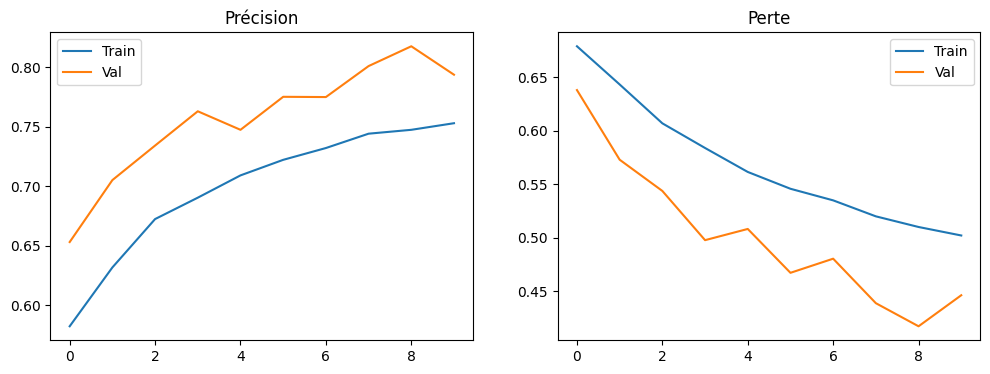

In [15]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Définition du modèle CNN
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Entraînement avec les générateurs du script
print("Début de l'entraînement...")
EPOCHS = 10
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=EPOCHS
)

# 4. Visualisation des résultats
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Perte')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Visualisation d'un échantillon d'images
x, y = next(train_flow)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x[i])
    label = "Chien" if y[i] == 1 else "Chat"
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
from tensorflow.keras import layers, models, callbacks

# 4 & 5. Optimisation et Entraînement avec EarlyStopping
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback pour arrêter l'entraînement si la perte de validation ne s'améliore plus
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Début de l'entraînement avec EarlyStopping...")
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=20,
    callbacks=[early_stop]
)

Début de l'entraînement avec EarlyStopping...
Epoch 1/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 187s 310ms/step - accuracy: 0.5759 - loss: 0.6838 - val_accuracy: 0.6595 - val_loss: 0.6214
Epoch 2/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 178s 303ms/step - accuracy: 0.6457 - loss: 0.6319 - val_accuracy: 0.6815 - val_loss: 0.5767
Epoch 3/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 177s 302ms/step - accuracy: 0.6825 - loss: 0.5924 - val_accuracy: 0.7132 - val_loss: 0.5571
Epoch 4/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 175s 299ms/step - accuracy: 0.7019 - loss: 0.5668 - val_accuracy: 0.7499 - val_loss: 0.5082
Epoch 5/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 177s 302ms/step - accuracy: 0.7160 - loss: 0.5503 - val_accuracy: 0.7794 - val_loss: 0.4976
Epoch 6/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 179s 305ms/step - accuracy: 0.7259 - loss: 0.5438 - val_accuracy: 0.7612 - val_loss: 0.4965
Epoch 7/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 176s 300ms/step - accuracy: 0.7352 - loss: 0.5266 - val_accuracy: 0.7762 - val_loss: 0.4724
Epoch 8/20
586/586 ━━━━━━━━━━━

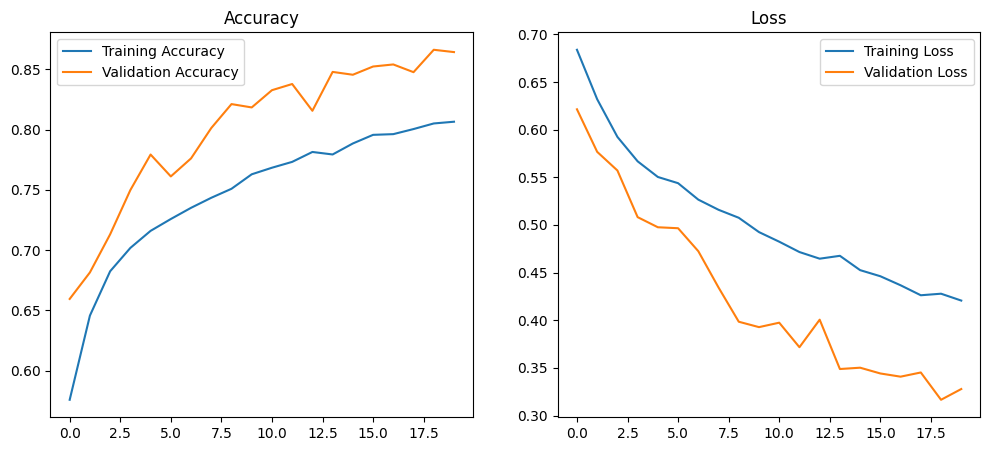

In [21]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step


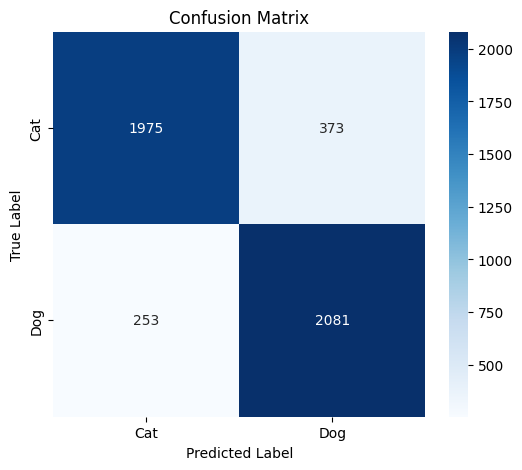


Classification Report
              precision    recall  f1-score   support

         Cat       0.89      0.84      0.86      2348
         Dog       0.85      0.89      0.87      2334

    accuracy                           0.87      4682
   macro avg       0.87      0.87      0.87      4682
weighted avg       0.87      0.87      0.87      4682



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

val_flow.reset()
Y_pred = model.predict(val_flow)
y_pred = (Y_pred > 0.5).astype(int).flatten()
y_true = val_flow.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print('\nClassification Report')
print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


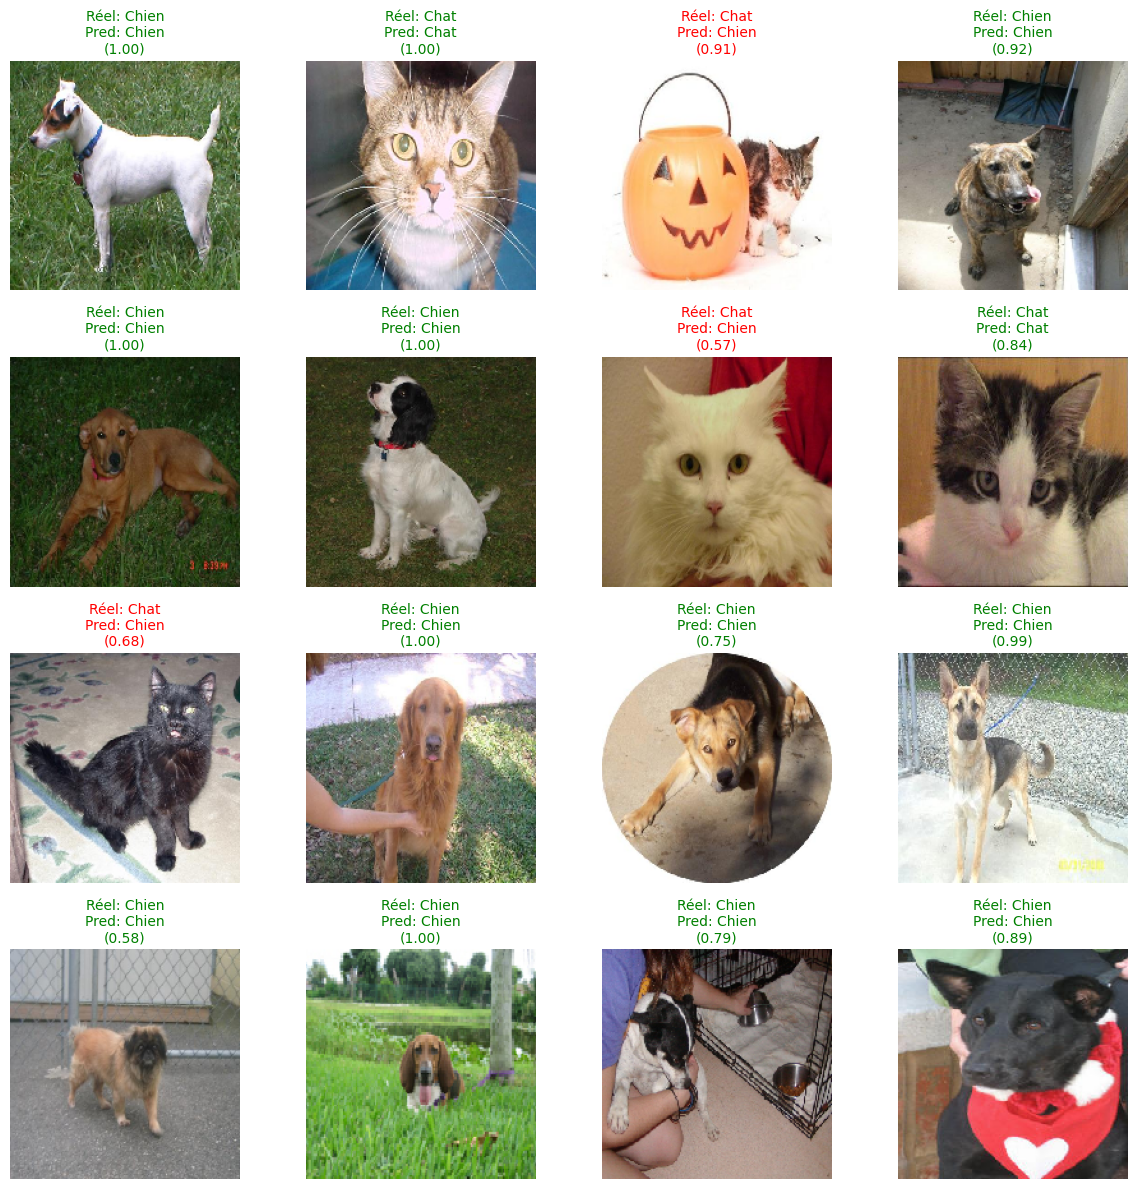

In [27]:
import matplotlib.pyplot as plt

# 8. Visualisation qualitative des prédictions
val_flow.reset()
x_batch, y_true_batch = next(val_flow)
preds = model.predict(x_batch)

plt.figure(figsize=(12, 12))
for i in range(min(16, len(x_batch))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_batch[i])

    actual = "Chat" if y_true_batch[i] == 0 else "Chien"
    predicted = "Chat" if preds[i] < 0.5 else "Chien"
    prob = preds[i][0] if preds[i] > 0.5 else 1 - preds[i][0]

    color = "green" if actual == predicted else "red"
    plt.title(f"Réel: {actual}\nPred: {predicted}\n({prob:.2f})", color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()